# Generalized Laplace Active Subspace UQ for molecular modeling with REINVENT

Notebook to reproduce the results from section *Autoregressive classification for molecular generative modelling* of

W.N. Edeling, P.V. Coveney, *Scalable Neural Network Uncertainty Quantification via Generalized Laplace
Active Subspaces*, 2026, (submitted).

We will consider the autoregressive framework of de-novo molecular design from [1]. Here, molecules are represented as simplified molecular-input line-entry specification (SMILES) strings, a sequence of characters corresponding to atoms, generated sequentially by a recurrent neural network trained to predict a discrete distribution for the next token. In particular, we use a LSTM network part of the REINVENT tookit [2] with approximately 1.6M weights, trained on SMILES strings from the ChEMBL database [3]. This makes molecular generation a sequence of autoregressive token-level classification problems since at each step, the network outputs a softmax distribution over the vocabulary, from which the next token is sampled.

We study here how the low-rank posterior uncertainty in the network (for both the standard and generalized scaling), affects free-running autoregressive molecular generation. This setting separates the intrinsic stochasticity of the softmax layer from epistemic variability induced by posterior weight perturbations.

The $M=34$ tokens that make up the SMILES vocabulary and some example ChEMBL molecules are found below.

**Table: Vocabulary used by the autoregressive SMILES generator.**
The vocabulary contains start and stop tokens, bond symbols, branch symbols, ring-closure indices, atom tokens, and charged or aromatic atom tokens.

| Index | Token | Description            | Index | Token  | Description                          |
| ----: | :---- | :--------------------- | ----: | :----- | :----------------------------------- |
|     0 | `$`   | Stop/end token         |    17 | `Br`   | Bromine atom                         |
|     1 | `^`   | Start token            |    18 | `C`    | Aliphatic carbon atom                |
|     2 | `#`   | Triple bond            |    19 | `Cl`   | Chlorine atom                        |
|     3 | `%10` | Two-digit ring closure |    20 | `F`    | Fluorine atom                        |
|     4 | `(`   | Branch opening         |    21 | `N`    | Aliphatic nitrogen atom              |
|     5 | `)`   | Branch closing         |    22 | `O`    | Oxygen atom                          |
|     6 | `-`   | Single bond            |    23 | `S`    | Sulfur atom                          |
|     7 | `1`   | Ring closure index     |    24 | `[N+]` | Positively charged nitrogen          |
|     8 | `2`   | Ring closure index     |    25 | `[N-]` | Negatively charged nitrogen          |
|     9 | `3`   | Ring closure index     |    26 | `[O-]` | Negatively charged oxygen            |
|    10 | `4`   | Ring closure index     |    27 | `[S+]` | Positively charged sulfur            |
|    11 | `5`   | Ring closure index     |    28 | `[n+]` | Positively charged aromatic nitrogen |
|    12 | `6`   | Ring closure index     |    29 | `[nH]` | Protonated aromatic nitrogen         |
|    13 | `7`   | Ring closure index     |    30 | `c`    | Aromatic carbon atom                 |
|    14 | `8`   | Ring closure index     |    31 | `n`    | Aromatic nitrogen atom               |
|    15 | `9`   | Ring closure index     |    32 | `o`    | Aromatic oxygen atom                 |
|    16 | `=`   | Double bond            |    33 | `s`    | Aromatic su                          |


**Table: Example SMILES strings from the ChEMBL database.**

| No. | SMILES                                                             |
| --: | ------------------------------------------------------------------ |
|   1 | `CC(C)C(NC(=O)C(NC(=O)C1OC2OC(C)(C)OC2C2OC(C)(C)OC12)C(C)C)C(O)=O` |
|   2 | `Fc1ccc(cc1)C(=O)NN1C(SCc2ccc(cc2)N(=O)=O)=Nc2ccccc2C1=O`          |
|   3 | `CC(C)CN1Cc2cnnn2-c2ccc(cc2C1)-c1ccccc1`                           |
|   4 | `CCN(C(=O)CSc1nnnn1-c1ccccc1)C1=C(N)N(Cc2ccccc2)C(=O)NC1=O`        |
|   5 | `CC(C)N1CCN(CC1)C(=O)N1c2ccccc2Sc2ccccc12`                         |
|   6 | `CC1(C)Cc2cc(OCc3ccc(cc3)-c3nn[nH]n3)c(Cl)c(Cl)c2C1=O`             |
|   7 | `Cc1cccc(CSc2ccc(cn2)C(=O)Nc2ccc(F)cc2)c1F`                        |
|   8 | `CCC(N1N=C(O)C2=Nc3cc(Cl)ccc3C(=O)C2=C1O)c1ccccn1`                 |
|   9 | `CC(N1C(=O)C2OC3(C)C=C(C)C=NC3C2C1=O)c1ccccc1`                     |
|  10 | `Cc1nc(cs1)-c1cccc(NC(=O)c2ccc3nc4C(=O)NCCCn4c3c2)c1`              |


[1] M. Olivecrona, T. Blaschke, O. Engkvist, and H. Chen, Molecular de-novo design through deep reinforcement learning, Journal of cheminformatics, 9 (2017), p. 48.

[2] H. Loeffler, J. He, A. Tibo, J. Janet, A. Voronov, L. Mervin, and O. Engkvist, Reinvent 4: Modern ai–driven generative molecule design, Journal of Cheminformatics, 16 (2024), p. 20.

[3] A. Gaulton, A. Hersey, M. Nowotka, A. Bento, J. Chambers, D. Mendez, P. Mutowo, F. Atkinson, L. Bellis, E. Cibri´an-Uhalte, et al., The chembl database in 2017, Nucleic acids research, 45 (2017), pp. D945–D954.

Missing packages can be installed using e.g.:

In [1]:
#!pip install tqdm

### REINVENT install

To use this notebook, the `reinvent` package needs to be installed. Instructions to do so are found here: https://github.com/MolecularAI/REINVENT4.

We use a pre-trained LSTM model, located in `./pre_trained_models/reinvent.prior`. 

In [2]:
import os
import subprocess

import torch
# to create a pytorch dataset
from torch.utils.data import Dataset
from torch.func import jvp, vjp, functional_call
from torch.nn.utils.rnn import pad_sequence

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

from reinvent import models
from reinvent.models.reinvent.models.vocabulary import SMILESTokenizer

# various subroutines we use for the generalized laplace active subspaces, see ./utils/__init__.py
import utils

In [3]:
# without this jvp fails due to:
# NotImplementedError: Trying to use forward AD with mkldnn_rnn_layer that does not support it because it has not been implemented yet.
torch.backends.mkldnn.enabled = False

Fix the random seeds

In [4]:
torch.manual_seed(0)
np.random.seed(0)

### Load pretrained model

The `model` we use is an instance of `reinvent.models.model.Model`. This subroutine loads a pre-trained `model` from `./pre_trained_models/reinvent.prior`. The core pytorch LSTM is then accessible via `model.network`.

In [5]:
def get_model(save_dict):
    """
    Load a pretrained Reinvent model.

    Parameters
    ----------
    save_dict : dict
        A dictionary containing dict_keys(['model_type', 'version', 
                                           'metadata', 'vocabulary',
                                           'tokenizer', 'max_sequence_length',
                                           'network', 'network_params']).

    Returns
    -------
    model : reinvent.models.model.Model
        A Reinvent model class.

    """

    model_type = 'Reinvent'
    model_class = getattr(models, f"{model_type}Model", None)
    mode = 'inference'
    model = model_class.create_from_dict(save_dict, mode, device)

    return model

In [6]:
device = torch.device('cpu')

# load pretrained model
save_dict = torch.load('./pre_trained_models/reinvent.prior', map_location='cpu', weights_only=False)
# the vocabulary displayed above
vocabulary = save_dict['vocabulary']['tokens']
n_tokens = len(vocabulary)
# the maximum allowed number of tokens per SMILES string
max_sequence_length = save_dict['max_sequence_length']
# tokenizer to break SMILES strings into tokens and v.v.
tokenizer = SMILESTokenizer()

# Reinvent model object, torch network in model.network
model = get_model(save_dict)
model.network.eval()

RNN(
  (_embedding): Embedding(34, 256)
  (_rnn): LSTM(256, 256, num_layers=3, batch_first=True)
  (_linear): Linear(in_features=256, out_features=34, bias=True)
)

### Extract the pretrained weights

In [7]:
# a dictionary containing the weights names and weights tensors
# (without a .clone() small changes can creep in the pretrained weights during sampling)
theta_0_dict = {
    name: p.detach().clone()
    for name, p in model.network.named_parameters()
}
# all the weights reshaped into a Dx1 tensor
theta_0 = utils.dict_to_vector(theta_0_dict, model.network).detach().clone()

# number of connection weights
D = theta_0.shape[0]
print(f'There are {D} connection weights')

There are 1596450 connection weights


### Load training data

There are 1.25M SMILES strings used to train the LSTM from the ChEMBL database located in `./data/train_smiles.smi`. The following class turns these into a pytorch dataset. It uses the `tokenizer` to turn these strings into a sequence of integers, corresponding to the keys of the `vocabulary`. Since not all SMILES strings are of equal length, this class applies padding with zeros (the stop token), such that all entries are of length `max_sequence_length`. 

A `mask` with True/False entries for real/padded tokens is computed to remove the padded entires when required.

As usual in next-token prediction, $(x,y)$ training pairs are just the integer sequences shifted by 1.

As outlined in the article, we subsample the data when computing the $Gv$ products for computational efficiency. If `generate_data = False`, we do not use `SmilesDataset` to convert the 1.25M SMILES into integer sequences, and instead directly load a subsampled dataset of 2000 integer sequences from `./data/train_data_n_sub_2000.pt`.

In [8]:
class SmilesDataset(Dataset):
    """
    Pytorch Dataset for Chembl smiles
    """

    def __init__(self, input_smiles_path):
        """
        Create a SmilesDataset object. Each smiles string will be 
        encoded as an integer sequence.

        Parameters
        ----------
        input_smiles_path : string
            The path to the file containing the smiles strings. This
            file should contain no headers and 1 smiles string per
            line.

        Returns
        -------
        None.

        """

        self.smiles = pd.read_csv(input_smiles_path, header=None).values
        self.n_data = self.smiles.shape[0]
        self.sequence_lengths = torch.zeros([self.n_data, 1], dtype=torch.int)

        data = []
        print('Converting smiles to integer sequences...')
        i = 0
        for smile in tqdm(self.smiles):
            tokens_i = [tokenizer.tokenize(data = smile[0])]
            idx_i = [model.vocabulary[token] for token in tokens_i[0]]
            self.sequence_lengths[i] = len(idx_i)
            data.append(torch.tensor(idx_i).to(device))
            i += 1

        # pad with 0 every entry after the stop token
        print('Padding sequences...')
        data = pad_sequence(data, batch_first=True, padding_value=0)
        T = data.shape[1]

        # create a mask with a False for all padded entries
        self.mask = torch.arange(T - 1).unsqueeze_(0) < self.sequence_lengths - 1
        self.data = data

    def __len__(self):
        """
        Get the data size.

        Returns
        -------
        int
            Number of (x, y) pairs.

        """
        return len(self.data)

    def __getitem__(self, idx):
        """
        Get 1 (x, y) training sample.

        If 0,1,2,3,4,5,6,7 is the sequence:

            x = 0,1,2,3,4,5,6
            y = 1,2,3,4,5,6,7

        Parameters
        ----------
        idx : int
            An index to the dataset.

        Returns
        -------
        x : list
            The input sequence.
        y : list
            The shifted output sequence containing the next tokens.

        """
        
        if type(idx) is int:
            idx = [idx]
        
        x = [self.data[i][0:-1] for i in idx]
        y = [self.data[i][1:] for i in idx]

        return x, y

In [9]:
# generate new (subsampled) data or load from disk
generate_data = False

In [10]:
# subsample the data
n_sub = 2000
train_file = f'./data/train_data_n_sub_{n_sub}.pt'

# use SmilesDataset to generate new data
if generate_data:
    # load (pre-processed) training data directly from file
    input_smiles_path = './data/train_smiles.smi'
    train_set = SmilesDataset(input_smiles_path)
    n_data = train_set.data.shape[0]
    idx = np.random.randint(0, n_data, n_sub)
    x = torch.Tensor(train_set.data)[idx, 0:-1]
    y = torch.Tensor(train_set.data)[idx, 1:]
    mask = train_set.mask[idx]
    torch.save({'x': x, 'y': y, 'mask': mask}, f'./data/train_data_n_sub_{n_sub}.pt')
# load processed, subsampled training data from disk
else:
    print(f'Loading training data from {train_file}')
    train_data = torch.load(train_file)
    x = train_data['x']
    y = train_data['y']
    mask = train_data['mask']
N = mask.sum().item()
print(f'There are {n_sub} SMILES consisting of {N} data points.')
x

Loading training data from ./data/train_data_n_sub_2000.pt
There are 2000 SMILES consisting of 93483 data points.


tensor([[ 1, 18, 21,  ...,  0,  0,  0],
        [ 1, 21, 30,  ...,  0,  0,  0],
        [ 1, 20, 18,  ...,  0,  0,  0],
        ...,
        [ 1, 18, 21,  ...,  0,  0,  0],
        [ 1, 18, 18,  ...,  0,  0,  0],
        [ 1, 19, 30,  ...,  0,  0,  0]])

The maximium subspace dimension that we consider

In [11]:
d_max = 3

### Extract the pretrained weights

In [12]:
# a dictionary containing the weights names and weights tensors
# (without a .clone() small changes can creep in the pretrained weights)
theta_0_dict = {
    name: p.detach().clone()
    for name, p in model.network.named_parameters()
}
# all the weights reshaped into a Dx1 tensor
theta_0 = utils.dict_to_vector(theta_0_dict, model.network).detach().clone()

### Choose scaling

The temperature parameter $\beta$ is used to select either the standard Bayesian scaling (related to the summed loss), or the generalized scaling (related to the mean loss).

In [13]:
beta = 1          # generalized scaling (classification)
# beta = N        # standard scaling (classification)

# a flag for the type of scaling used: generalized or standard
if beta > 1: scaling = 'std'
else: scaling = 'gen'

### Matrix-free $G$ eigenmodes

Here we compute the dominant eigenvalues/vectors of $G$ using matrix-free $Gv$ products and the Lanczos algorithm, see Section *Matrix-free computation of dominant eigenpairs*.

To load precomputed eigenmodes from disk, set `compute_eigmodes = False`.

In [46]:
compute_eigmodes = False
if compute_eigmodes:
    m = d_max + 10 
    Q, T = utils.lanczos(m, D, model.network, theta_0_dict, x, N, batch_size = 128, classification = True, mask = mask)
    # eigen decomposition of small matrix
    eigvals, eigvecs_T = torch.linalg.eigh(T)
    # map back to parameter space
    eigvecs = Q @ eigvecs_T
    # reserve sorting order, which is standard from low to high eigenvalues
    eigvals = eigvals.flip(0)
    eigvecs = eigvecs.flip(1)
    torch.save({'eigvals':eigvals, 'eigvecs': eigvecs}, './data/eigmodes.pt')
else:
    eigmodes = torch.load('./data/eigmodes.pt')
    eigvals = eigmodes['eigvals']
    eigvecs = eigmodes['eigvecs']

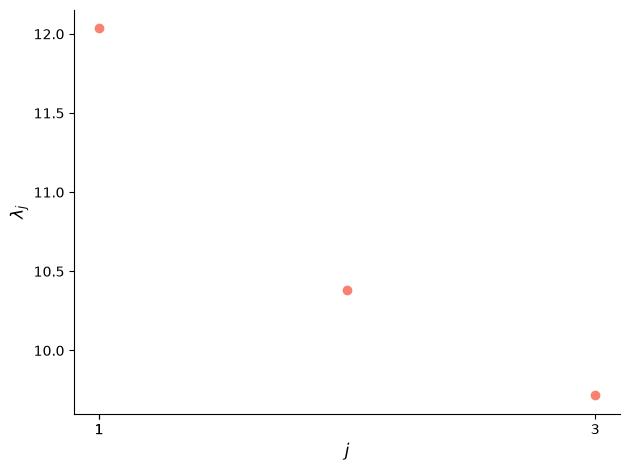

In [15]:
# plot the eigenvalues
with torch.no_grad():
    # plot the d leading eigenvalues
    fig = plt.figure('eigvals')
    ax = fig.add_subplot(111)
    p1 = ax.plot(np.arange(1, d_max+1), eigvals[0:d_max], 'o', color = 'salmon', label='matrix-free')
    ax.set_ylabel(r'$\lambda_j$', fontsize=12)
    ax.set_xlabel(r'$j$', fontsize=12)
    ax.set_xticks([1, int(d_max/2), d_max])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

### Emprical Bayes for $\sigma_0$ and calibration of $d$

We use an empirical Bayesian procedure to estimate the prior variance $\sigma_0^2$ from the data $y$, see section *"Empirical generalized Bayesian subspace inference for the prior variance"*.

Here we select a $d$ and solve for $\sigma^2_0$ by solving

\begin{align}
\lVert w_0\rVert^2_2 = \sum_{i=1}^d \frac{1}{\alpha} - \frac{1}{\beta\lambda_i + \alpha} = \sum_{i=1}^d \sigma^2_0 - \sigma^2_i,
\end{align}

via the bisection method (`utils.solve_sigma0_lowrank`). 

In [16]:
d = 1
theta_0_projected = eigvecs[:, 0:d].T @ theta_0
theta_norm_sq_projected = (theta_0_projected**2).sum().item()
sigma0_sq = utils.solve_sigma0_lowrank(eigvals[0:d], theta_norm_sq_projected, D, d, beta)
sigma_0 = np.sqrt(sigma0_sq)
sigma_sq_post = 1 / (beta * eigvals[0:d] + 1 / sigma_0 ** 2)
sigma_post = sigma_sq_post.sqrt()

print(f'Active subspace dimension d = {d}, prior std. dev. = {sigma_0:.3e}')

Converged to root within 3.48e-03
alpha = 32.000000005
Active subspace dimension d = 1, prior std. dev. = 1.768e-01


### Contraction ratio

Plot the contraction ratio for the first `d_max` dominant directions of the $G$ eigenspace:

\begin{align}
c_i := \frac{\beta \lambda_i}{ \beta \lambda_i + \frac{1}{\sigma^2_0}},
\end{align}

for which $c_i = 1$ implies that the $i$-th direction is strongly data-informed, and values close to zero denote prior-dominated directions.

In the same figure we plot the posterior variance $\sigma_j^2$.

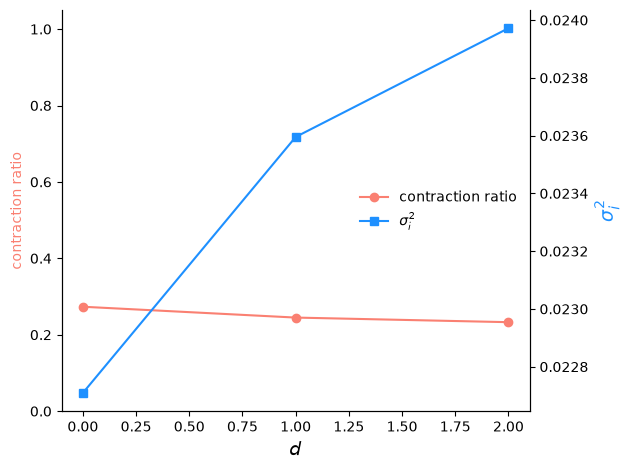

In [17]:
with torch.no_grad():
    eigvals_np = eigvals.cpu().numpy().flatten()
    contraction_ratio = beta * eigvals_np / (beta * eigvals_np + 1 / sigma_0 ** 2)
    var_post = 1 / (beta * eigvals_np + 1 / sigma_0 ** 2)

    fig = plt.figure()
    ax = fig.add_subplot(111, ylim=[0,1.05])
    p1 = ax.plot(contraction_ratio[0:d_max], '-o', color = 'salmon', label='contraction ratio')
    ax.set_xlabel(r'$d$', fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.set_ylabel('contraction ratio', color='salmon')
    
    ax2 = ax.twinx()
    p2 = ax2.plot(var_post[0:d_max], '-s', color = 'dodgerblue', label=r'$\sigma^2_i$')
    ax2.spines['top'].set_visible(False)
    ax2.set_yscale('linear')
    ax2.set_ylabel(r'$\sigma^2_i$', color='dodgerblue', fontsize=14)
    
    lns = p1 + p2
    labs = [l.get_label() for l in lns]
    plt.legend(lns, labs, loc=5, frameon=False, draggable=True)
    plt.tight_layout()

    fig.savefig('./images/contraction_ratio_reinvent.png', dpi=300)

In [18]:
# set the final eigenvalues/vectors
sigma_post = sigma_post[0:d]
eigvecs = eigvecs[:, 0:d]

### Generative posterior sampling

We study here how the low-rank posterior uncertainty in the network (for both the standard and generalized scaling), affects free-running autoregressive molecular generation. This setting separates the intrinsic stochasticity of the softmax layer from epistemic variability induced by posterior weight perturbations.


In [25]:
# the total number of SMILES string to be generated
n_mc = 10000
# how many SMILES strings to generate in one batch
batch_size = 10
# the number of iterations
n_iter = int(n_mc / batch_size)

This will run the generative sampling on the baseline model, i.e. softmax-only stochasticity. It will store the generated SMILES strings in `./scoring/smiles_baseline.smi`. This will only need to be executed once.

In [ ]:
run_baseline = False
# run the baseline model sampling
if run_baseline:

    print(f'Generating {n_mc} molecules using the baseline model...')
    smiles_baseline = []
    nlls_baseline = []

    for _ in tqdm(range(n_iter)):
        # get the smiles strings, associated integer sequences, and neg. log likelihood values
        smiles_, seqs_, nlls_ = utils.sample_reinvent(batch_size, model, theta_0, theta_0_dict, sigma_post, eigvecs, 
                                                      device, vocabulary, tokenizer)
        smiles_baseline += smiles_
        nlls_baseline += nlls_
    nlls_baseline = [i.item() for i in nlls_baseline]

    # store the smiles string to disk
    with open('./scoring/smiles_baseline.smi', 'w') as fp:
        for smile in smiles_baseline:
            fp.write(smile + '\n')

From the generated SMILES strings, we compute the following quantities of interest (QoIs) by running REINVENT in "scoring" mode.

| Quantity | Description |
|---|---|
| Molecular weight | Molecular size based on atomic masses; large values indicate large molecules. |
| SA score | Synthetic Accessibility score; higher values indicate more difficult synthesis. |
| SlogP | Estimate of how fat-soluble a molecule is. |

This occurs via the commandline: `reinvent -l scoring_baseline.log ./scoring/QoIs_baseline.toml`. Here `./scoring/QoIs_baseline.toml` is a config file specifying which QoIs we wish to compute.

In [20]:
    # run reinvent in scoring mode via command line
    print('Running scoring...')
    cmd = [
        "reinvent",
        "-l",
        "scoring_baseline.log",
        "./scoring/QoIs_baseline.toml",
    ]
    subprocess.run(cmd, check=True)
    print('done.')

Load the scoring results from a CSV file

In [37]:
results_baseline = pd.read_csv('./scoring/scoring_baseline.csv')
results_baseline

,SMILES,Comment,RDKit_SMILES (REINVENT),Score,MW,Number of Heavy atoms,Number of HB acceptors (Lipinski),Number of HB donors (Lipinski),Number of aromatic rings,SlogP (RDKit),Number of rotatable bonds,SA score,MW (raw),Number of Heavy atoms (raw),Number of HB acceptors (Lipinski) (raw),Number of HB donors (Lipinski) (raw),Number of aromatic rings (raw),SlogP (RDKit) (raw),Number of rotatable bonds (raw),SA score (raw)
0,CN1Cc2ncn(CC3CCCC3)c2C(=O)C1,NaN,CN1CC(=O)c2c(ncn2CC2CCCC2)C1,1.093670e+00,0.955571,0.998225,1.0,0.996848,0.872007,8.479844e-01,0.990099,2.940247,233.315,17.0,3.0,0.0,1.0,1.70140,2.0,2.940247
1,Brc1cnc(nc1SCC#N)N1CCCC1,NaN,N#CCSc1nc(N2CCCC2)ncc1Br,7.942120e-01,0.999892,0.998534,1.0,0.996848,0.872007,6.792086e-02,0.982528,2.733243,299.197,16.0,5.0,0.0,1.0,2.45498,3.0,2.733243
2,COc1cc(N=C2CCCCC2(C)Cc2ccccc2)cc1Cl,NaN,NaN,1.000000e-08,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000
3,COc1cccc(c1)C(=O)NC(=S)NN=Cc1ccc(OC)cc1,NaN,COc1ccc(C=NNC(=S)NC(=O)c2cccc(OC)c2)cc1,5.894983e-01,0.999998,0.993233,1.0,0.500000,0.127993,1.224037e-01,0.946760,1.979790,343.408,24.0,5.0,2.0,2.0,2.34220,5.0,1.979790
4,CCCCCC(C)C(=O)OC1C(O)CC2(O)C3CCC4(C)C33C=CC=C(...,NaN,NaN,1.000000e-08,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CC(C)(C)C1NCc2ccccc12,NaN,CC(C)(C)C1NCc2ccccc21,4.389199e-01,0.093024,0.999175,1.0,0.946760,0.872007,6.378532e-03,0.996848,2.823162,175.275,13.0,1.0,1.0,1.0,2.87700,0.0,2.823162
9996,CCc1nc(SCc2ccccc2)c2NC(=O)C(C)=C(c3nc4cccc(c3)...,NaN,NaN,1.000000e-08,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000
9997,O=C(CNC(=O)CN1CSCC1Oc1ccccc1)N1CCCC1,NaN,O=C(CN1CSCC1Oc1ccccc1)NCC(=O)N1CCCC1,1.103562e+00,0.999999,0.993233,1.0,0.946760,0.872007,9.931135e-01,0.909091,2.971369,349.456,24.0,5.0,1.0,1.0,1.13640,6.0,2.971369
9998,CN1CCN(Cc2ccc(Cl)cc2)C(=O)c2ccc3CN(Cc4cc(F)ccc...,NaN,CN1CCN(Cc2ccc(Cl)cc2)C(=O)C2=CC=C3CN(Cc4cc(F)c...,2.013657e-02,0.000218,0.849020,1.0,0.996848,0.003152,0.000000e+00,0.990099,4.684628,591.514,41.0,4.0,0.0,3.0,5.73640,2.0,4.684628


Below we repeat the procedure for the softmax + Laplace case:

In [ ]:
print(f'Generating {n_mc} molecules using the Laplace model...')
smiles_laplace = []
nlls_laplace = []

for _ in tqdm(range(n_iter)):
    smiles_, seqs_, nlls_ = utils.sample_reinvent(batch_size, model, theta_0, theta_0_dict, sigma_post, eigvecs, 
                                                  device, vocabulary, tokenizer, laplace=True, d = d)
    smiles_laplace += smiles_
    nlls_laplace += nlls_
nlls_laplace = [i.item() for i in nlls_laplace]

In [23]:
print('Running scoring...')
# run reinvent in scoring mode via command line
with open(f'./scoring/smiles_laplace_{scaling}_scaling.smi', 'w') as fp:
    for smile in smiles_laplace:
        fp.write(smile + '\n')
cmd = [
    "reinvent",
    "-l",
    f"scoring_{scaling}.log",
    f"./scoring/QoIs_laplace_{scaling}_scaling.toml",
]
subprocess.run(cmd, check=True)
print('done.')

Running scoring...
done.


In [38]:
results_laplace = pd.read_csv(f'./scoring/scoring_laplace_{scaling}_scaling.csv')
results_laplace

,SMILES,Comment,RDKit_SMILES (REINVENT),Score,MW,Number of Heavy atoms,Number of HB acceptors (Lipinski),Number of HB donors (Lipinski),Number of aromatic rings,SlogP (RDKit),Number of rotatable bonds,SA score,MW (raw),Number of Heavy atoms (raw),Number of HB acceptors (Lipinski) (raw),Number of HB donors (Lipinski) (raw),Number of aromatic rings (raw),SlogP (RDKit) (raw),Number of rotatable bonds (raw),SA score (raw)
0,Cc1cccc(NC(=O)COc2ccc3nc(Br)ccc4s3)nc2c(c1)-c1...,NaN,NaN,1.000000e-08,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000
1,NS(=O)(=O)c1ccc(cc1)-c1nc(oc2ccccc12)-c1ccccc1,NaN,NaN,1.000000e-08,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000
2,COc1ccccc1Nc1c2C=C(C(C)C)C(=O)Nc2cc2oc(cc(C(O)...,NaN,NaN,1.000000e-08,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000
3,CC(CNCCc1c[nH]cn1)Nc1ccc(C(=O)Nc2ccc(s2)C#N)c(...,NaN,NaN,1.000000e-08,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000
4,CCOC(=O)C1=CN(Cc2ccc(Br)cc2)C(=O)c2ccccc2NC1=O,NaN,CCOC(=O)C1=CN(Cc2ccc(Br)cc2)C(=O)c2ccccc2NC1=O,2.938088e-01,0.998520,0.988030,1.0,0.946760,0.127993,1.876950e-04,0.969347,2.552894,429.270,27.0,4.0,1.0,2.0,3.49060,4.0,2.552894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Clc1ccccc1Cc1noc(n1)-c1ccc(cc1)C(=O)N1CCCCC1,NaN,O=C(c1ccc(-c2nc(Cc3ccccc3Cl)no2)cc1)N1CCCCC1,8.096898e-02,0.999981,0.988030,1.0,0.996848,0.003152,2.980232e-07,0.969347,2.059684,381.863,27.0,4.0,0.0,3.0,4.60690,4.0,2.059684
9996,Cc1nc(CC(=O)OCC(=O)N2CCOCC2)c(-c2ccccc2OCCCCCN...,NaN,NaN,1.000000e-08,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000
9997,O=C1OOC1=C1C(=O)Nc2c1cnn2-c1ccccc1F,NaN,O=C1Nc2c(cnn2-c2ccccc2F)C1=C1OOC1=O,8.889059e-01,0.999675,0.996183,1.0,0.946760,0.127993,9.919831e-01,0.994408,3.274557,287.206,21.0,5.0,1.0,2.0,1.16300,1.0,3.274557
9998,CCOC(=O)C1=CN(Cc2ccccc2F)C2(CCCCC2)C1c1cccn1C,NaN,CCOC(=O)C1=CN(Cc2ccccc2F)C2(CCCCC2)C1c1cccn1C,1.135645e-01,0.999927,0.982528,1.0,0.996848,0.127993,5.960465e-08,0.946760,3.911035,396.506,29.0,3.0,0.0,2.0,4.91350,5.0,3.911035


Plot the kernel density estimates of the QoIs.

In [40]:
def plot_kde(qoi, show_legend = True, log = False):
    """
    Plot the kernel density estimates

    Parameters
    ----------
    qoi : string
        The name of the quantity of interest.
    show_legend : boolean, optional
        Flag for showing/hiding the legend.
    log : boolean
        Flag for using a logarithmic x axis.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure handle

    """

    fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True, figsize=(8,4))
    ax1.set_title('standard scaling')
    ax2.set_title('generalized scaling')

    idx_valid = np.where(results_baseline['MW (raw)'].values > 0)[0]
    qoi_baseline = results_baseline[qoi].values[idx_valid]
    kde_baseline = stats.gaussian_kde(qoi_baseline)
    dom_baseline = np.linspace(min(qoi_baseline), max(qoi_baseline), 100)

    ax1.plot(dom_baseline, kde_baseline(dom_baseline), color='dodgerblue', label='baseline')
    ax2.plot(dom_baseline, kde_baseline(dom_baseline), color='dodgerblue')

    for d in range(1, d_max + 1):

        idx_valid = np.where(results_laplace['std'][d]['MW (raw)'].values > 0)[0]
        qoi_std = results_laplace['std'][d][qoi].values[idx_valid]
        kde_std = stats.gaussian_kde(qoi_std)
        dom_std = np.linspace(min(qoi_std), max(qoi_std), 100)

        idx_valid = np.where(results_laplace['gen'][d]['MW (raw)'].values > 0)[0]
        qoi_gen = results_laplace['gen'][d][qoi].values[idx_valid]
        kde_gen = stats.gaussian_kde(qoi_gen)
        dom_gen = np.linspace(min(qoi_gen), max(qoi_gen), 100)

        ax1.plot(dom_std, kde_std(dom_std), line_style[d-1], color = colors[d-1], label=f'laplace (d={d})')
        ax2.plot(dom_gen, kde_gen(dom_gen), line_style[d-1], color = colors[d-1])

    if log: ax1.set_xscale('log')

    ax1.spines['top'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_xlabel(lbl[qoi], fontsize=12)
    ax1.yaxis.set_visible(False)

    ax2.spines['top'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.set_xlabel(lbl[qoi], fontsize=12)
    ax2.yaxis.set_visible(False)

    if show_legend: ax1.legend(loc = 0, draggable = True, frameon = False)
    plt.tight_layout()

    return fig

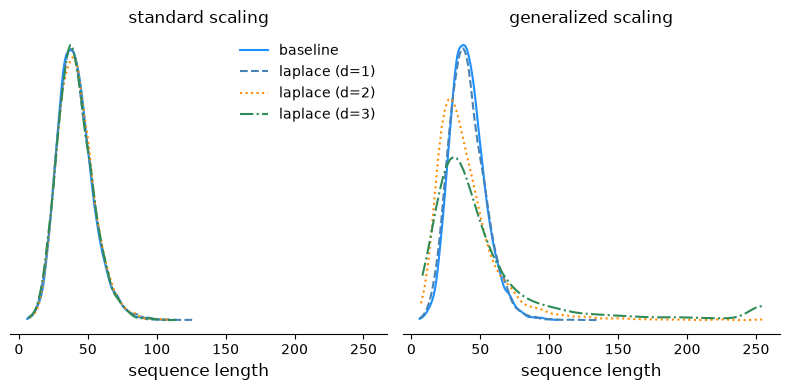

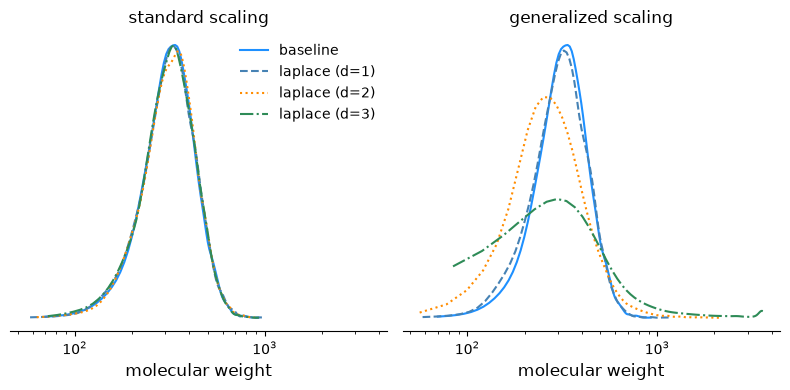

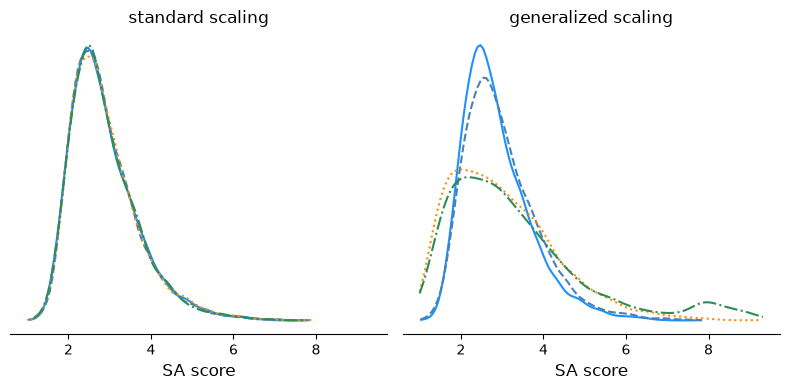

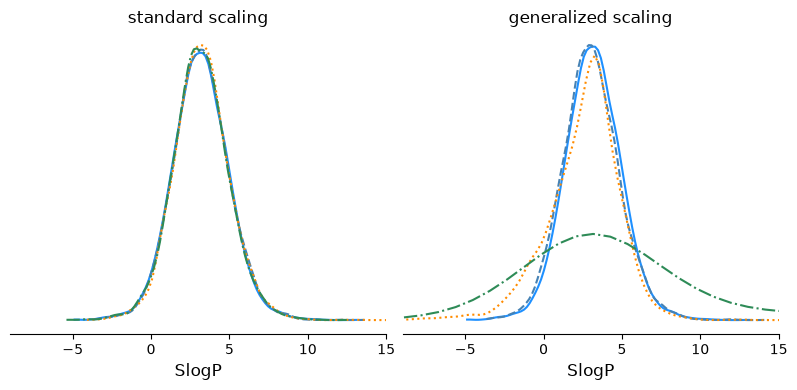

In [44]:
seq_length = np.array([len(tokenizer.tokenize(smile)) - 2 for smile in results_baseline['SMILES']])
results_baseline['seq_length'] = seq_length

results_laplace = {}
results_laplace['std'] = {}
results_laplace['gen'] = {}

lbl = {'MW': 'molecular weight (normalized)',
       'MW (raw)': 'molecular weight', 
       'SA score (raw)': 'SA score',
       'seq_length': 'sequence length',
       'SlogP (RDKit)': 'SlogP (normalized)',
       'SlogP (RDKit) (raw)': 'SlogP'}

line_style = ['--', ':', '-.']
colors = ['steelblue', 'darkorange', 'seagreen']

for d in range(1, d_max + 1):
    results_laplace['std'][d] = pd.read_csv(f'./scoring/scoring_laplace_std_scaling_d_{d}.csv')
    seq_length = np.array([len(tokenizer.tokenize(smile)) - 2 for smile in results_laplace['std'][d]['SMILES']])
    results_laplace['std'][d]['seq_length'] = seq_length

    results_laplace['gen'][d] = pd.read_csv(f'./scoring/scoring_laplace_gen_scaling_d_{d}.csv')
    seq_length = np.array([len(tokenizer.tokenize(smile)) - 2 for smile in results_laplace['gen'][d]['SMILES']])
    results_laplace['gen'][d]['seq_length'] = seq_length

fig = plot_kde('seq_length')
fig.savefig('./images/seq_length.png', dpi=300)

fig = plot_kde('MW (raw)', log=True)
fig.savefig('./images/MW.png', dpi=300)

fig = plot_kde('SA score (raw)', show_legend=False)
fig.savefig('./images/SA.png', dpi=300)

fig = plot_kde('SlogP (RDKit) (raw)', show_legend=False)
ax = fig.gca()
ax.set_xlim([-9, 15])
fig.savefig('./images/SlogP.png', dpi=300)

In [45]:
# print statements
print(f'==================== {scaling} scaling ====================')
print(f'{n_valid_baseline} out of {n_mc} baseline SMILES strings are valid')
print(f'{n_valid_laplace} out of {n_mc} laplace (d={d}) SMILES strings are valid')

==================== gen scaling ====================
8692 out of 10000 baseline SMILES strings are valid
5307 out of 10000 laplace (d=3) SMILES strings are valid


### Activity scores

Activity scoresare (first-order) sensitivity indices for individual parameters, which can be extracted from the active subspace eigenmodes. Analogously, using the $G$ eigenmodes, we define the activity scores for individual connection weights as:

\begin{align}
    \nu_i = \sum_{j=1}^d \lambda_j p_{j, i}^2, \quad i=1,\cdots,D.
\end{align}

Here $p_{j, i}$ is the $i$-th component of the $j$-th eigenvector of $G$.

However, rather than plotting individual $\nu_i$, we first sort from largest to smallest and instead plot the cumulative scores

\begin{align}
    \kappa_i = \frac{\sum_{j=1}^i \nu_j}{\sum_{j=1}^D \nu_j},\quad i=1,\cdots,D,
\end{align}

in a log-log plot.

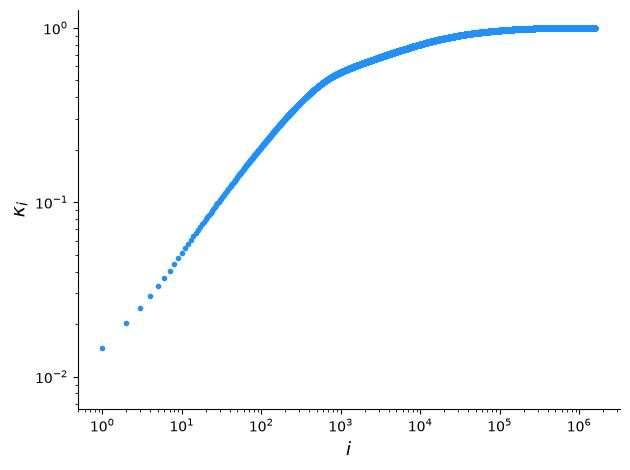

In [30]:
with torch.no_grad():

    # activity scores
    nu = 0.
    for j in range(d):
        nu += eigvals[j] * eigvecs[:, j] ** 2
    nu = np.sort(nu.numpy())[::-1]
    kappa_i = np.cumsum(nu[0:n_plot])/np.sum(nu)

    # plot all D cumulative (normalised) activity scores
    n_plot = D
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(np.arange(n_plot), kappa_i, '.', color='dodgerblue')   
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel(r'$\kappa_i$', fontsize=14)
    ax.set_xlabel(r'$i$', fontsize=14)  
    plt.xscale('log')
    plt.yscale('log')
    plt.tight_layout()

In [35]:
i = np.where(kappa_i > 0.99)[0][0]
print(f'The first {i / D * 100:.1f}% of the connection weights account for 99% of the curvature energy.')

The first 16.1% of the weights account for 99% of the curvature energy.
